# Simple Example

Let's have a look at the different [PlantUML](https://plantuml.com/) diagrams that the `cwl2puml` APIs are able to generate, given, for example, the [conditional-workflows](https://raw.githubusercontent.com/eoap/how-to/refs/heads/main/cwl-workflows/conditional-workflows.cwl) Workflow.

In [1]:
pip install cwl-loader

Note: you may need to restart the kernel to use updated packages.


## 1. Parsing

It is needed to read first a CWL document from a remote public URL:

In [2]:
from collections.abc import Mapping

from cwl_loader import load_cwl_from_location
from cwl_loader.utils import to_index
from cwl_utils.parser import Process

cwl_document: Process | list[Process] = load_cwl_from_location('https://raw.githubusercontent.com/eoap/how-to/refs/heads/main/cwl-workflows/conditional-workflows.cwl')
cwl_index: Mapping[str, Process] = to_index(cwl_document) if isinstance(cwl_document, list) else to_index([cwl_document])

2026-09-15 19:17:31.145 | DEBUG    | cwl_loader:load_cwl_from_location:368 - Loading CWL document from https://raw.githubusercontent.com/eoap/how-to/refs/heads/main/cwl-workflows/conditional-workflows.cwl...
2026-09-15 19:17:31.581 | DEBUG    | cwl_loader:_load_cwl_from_stream:371 - Reading stream from https://raw.githubusercontent.com/eoap/how-to/refs/heads/main/cwl-workflows/conditional-workflows.cwl...
2026-09-15 19:17:31.593 | DEBUG    | cwl_loader:load_cwl_from_stream:338 - CWL data of type <class 'ruamel.yaml.comments.CommentedMap'> successfully loaded from stream
2026-09-15 19:17:31.593 | DEBUG    | cwl_loader:load_cwl_from_yaml:261 - No needs to update the Raw CWL document since it targets already the v1.2
2026-09-15 19:17:31.594 | DEBUG    | cwl_loader:load_cwl_from_yaml:265 - Parsing the raw CWL document to the CWL Utils DOM...
2026-09-15 19:17:34.600 | DEBUG    | cwl_loader:load_cwl_from_yaml:274 - Raw CWL document successfully parsed to the CWL Utils DOM!
2026-09-15 19:17:3

## 2. PlantUML diagrams

The samples below show how to render CWL document to a specific PlantUML diagram:

In [3]:
from cwl2puml import (
    to_puml,
    DiagramType
)
from cwl_utils.parser import InputEnumSchema
from io import (
    StringIO,
    BytesIO
)
from IPython.display import display_png
from plantuml import deflate_and_encode
from PIL import Image
from urllib.request import urlopen

def render(
    diagram_type: DiagramType,
    debug: bool = False
):
    out = StringIO()
    to_puml(
        cwl_document=cwl_index,
        workflow_id='main', # 'main' by default, but define it for demo purposes
        diagram_type=diagram_type,
        output_stream=out
    )

    clear_output = out.getvalue()

    if debug:
        print(clear_output)

    encoded = deflate_and_encode(clear_output)
    diagram_url = f"https://uml.planttext.com/plantuml/png/{encoded}"

    with urlopen(diagram_url) as url:
        img = Image.open(BytesIO(url.read()))
    display_png(img)

### 2.1 Activity diagram

The [activity](https://plantuml.com/activity-diagram-beta) diagram represents the overall CWL document instructions.

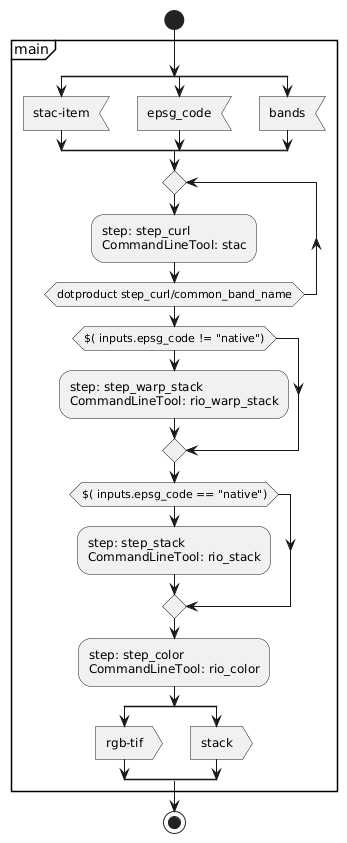

In [4]:
render(DiagramType.ACTIVITY)

### 2.2 Component diagram

The [component](https://plantuml.com/component-diagram) diagram represents the CWL document like chips on a motherboard.

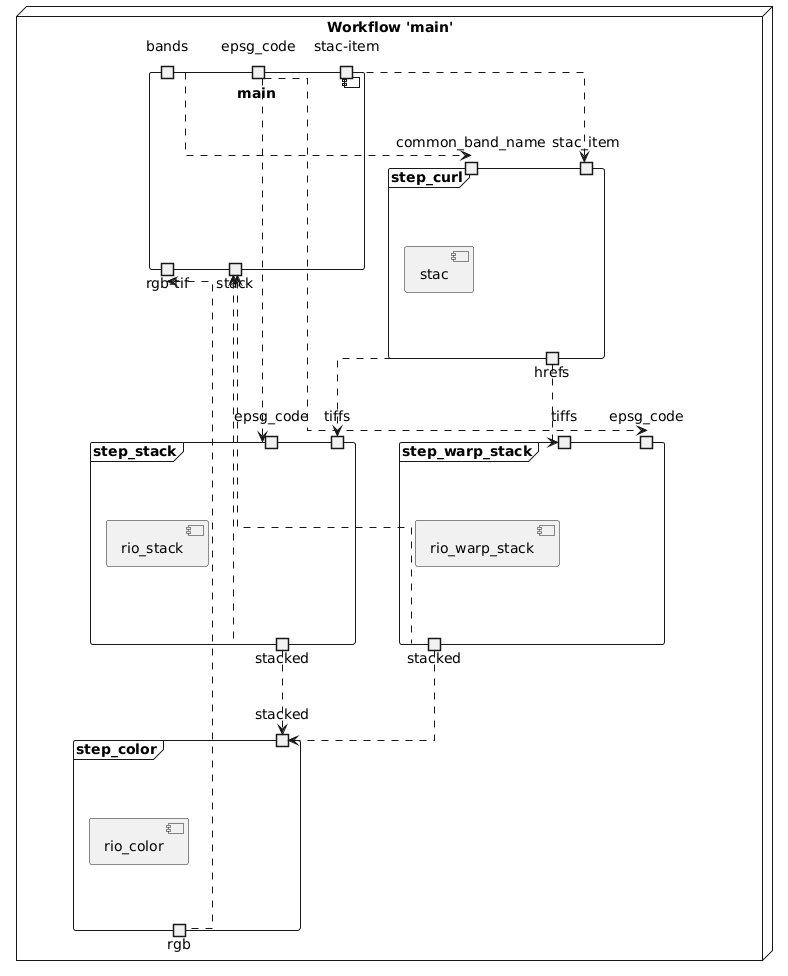

In [5]:
render(DiagramType.COMPONENT)

### 2.3 Class diagram

The [class](https://plantuml.com/class-diagram) diagram represents the CWL document like specifications of the previously illustrated chips on a motherboard.

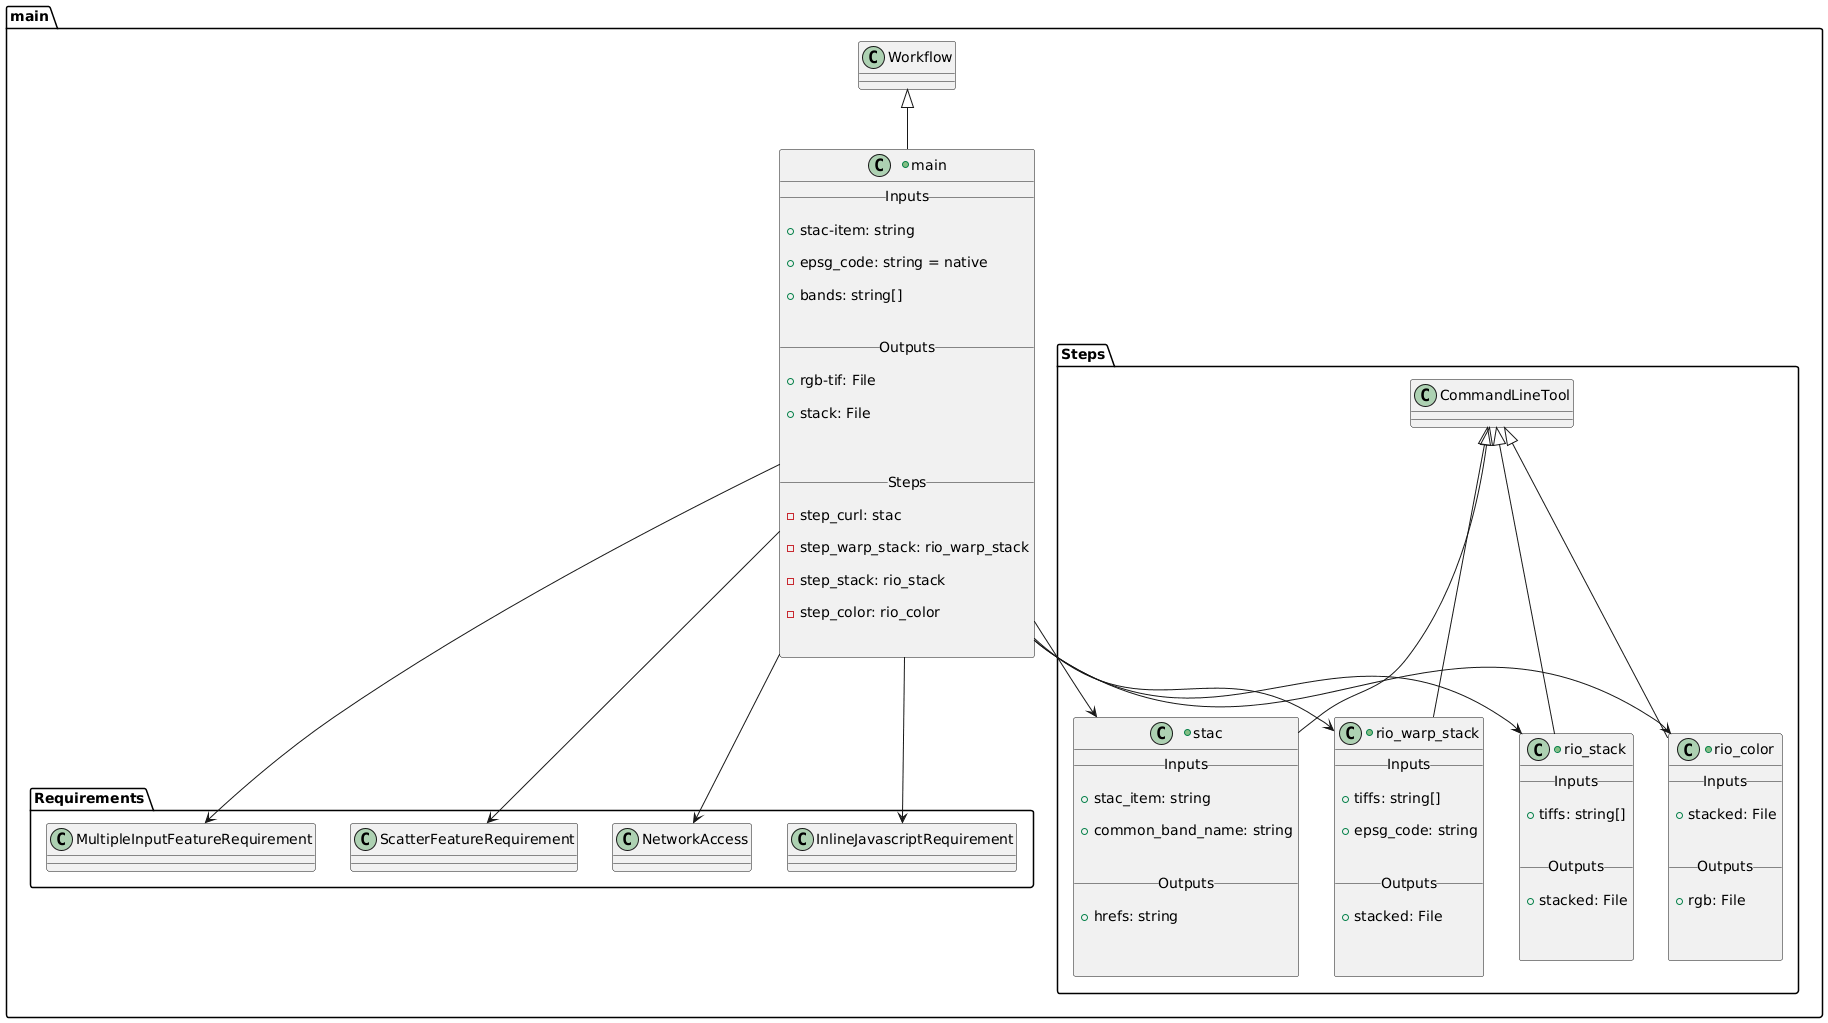

In [6]:
render(DiagramType.CLASS)

### 2.4 Sequence diagram

The [sequence](https://plantuml.com/sequence-diagram) diagram represents how the previously illustrated chips on a motherboard are triggered and interact with each other.

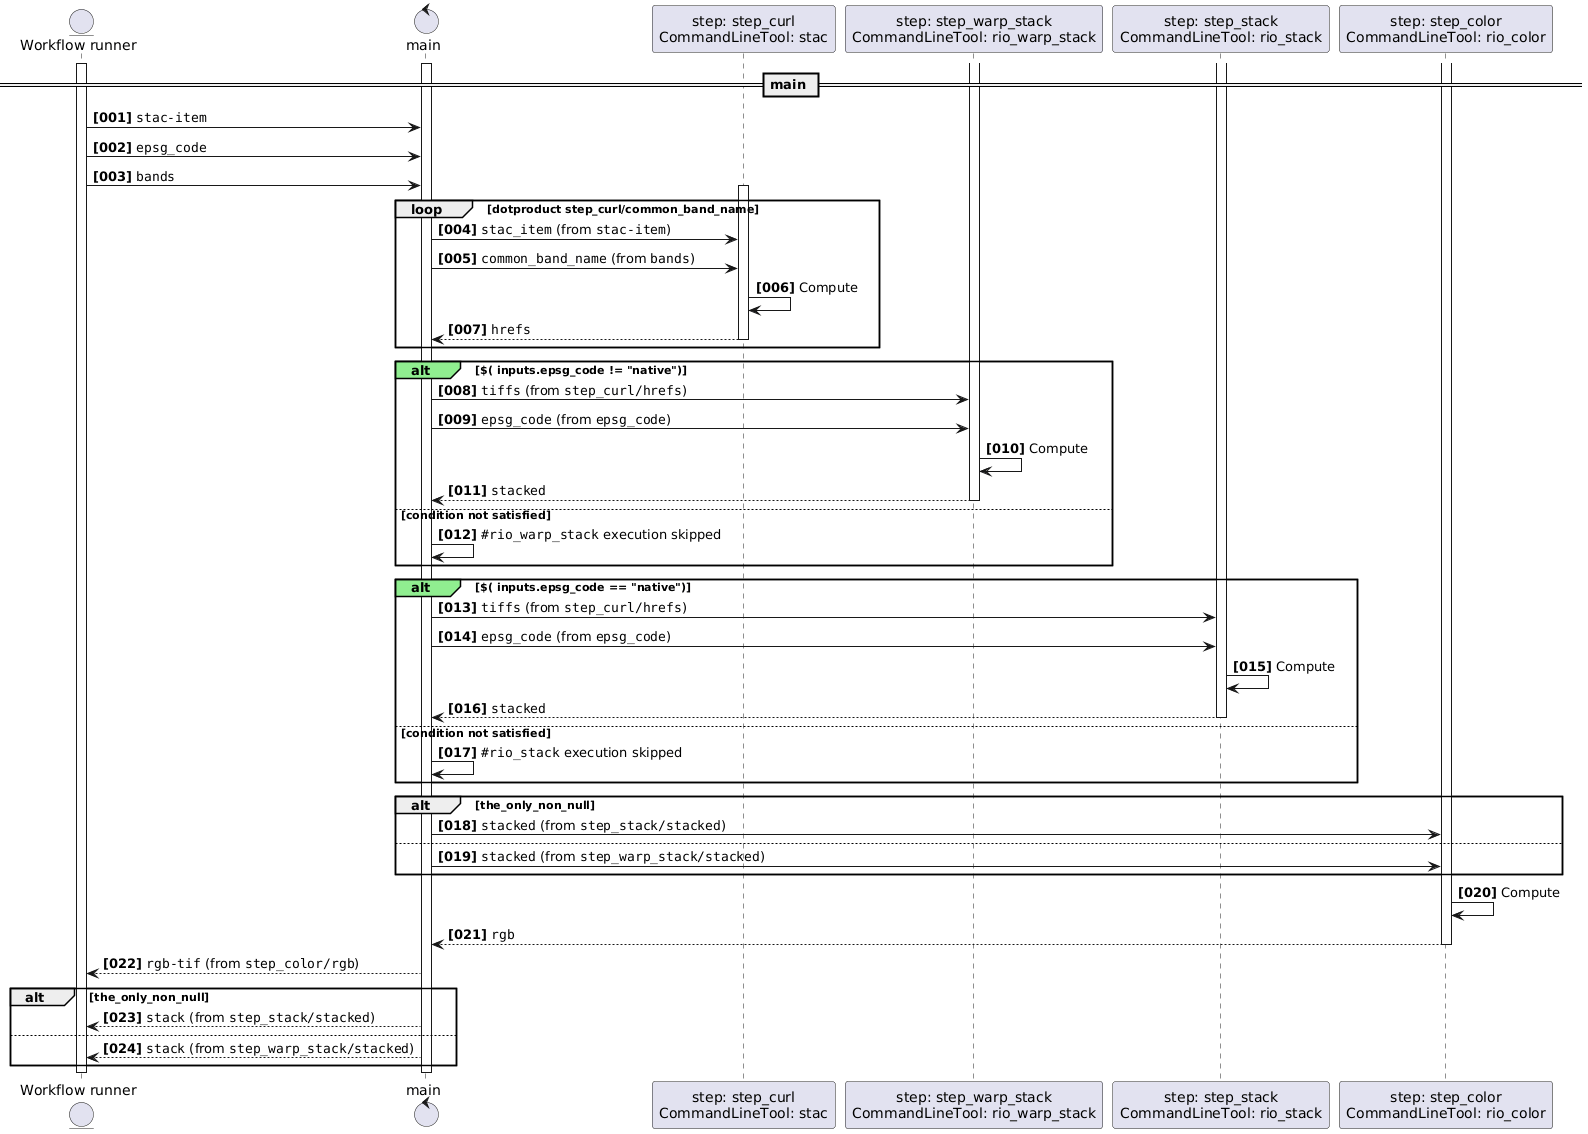

In [7]:
render(DiagramType.SEQUENCE)

### 2.5 State diagram

The [state](https://plantuml.com/state-diagram) diagram represents the dependencies between the inputs/outputs of the previously illustrated chips on a motherboard.

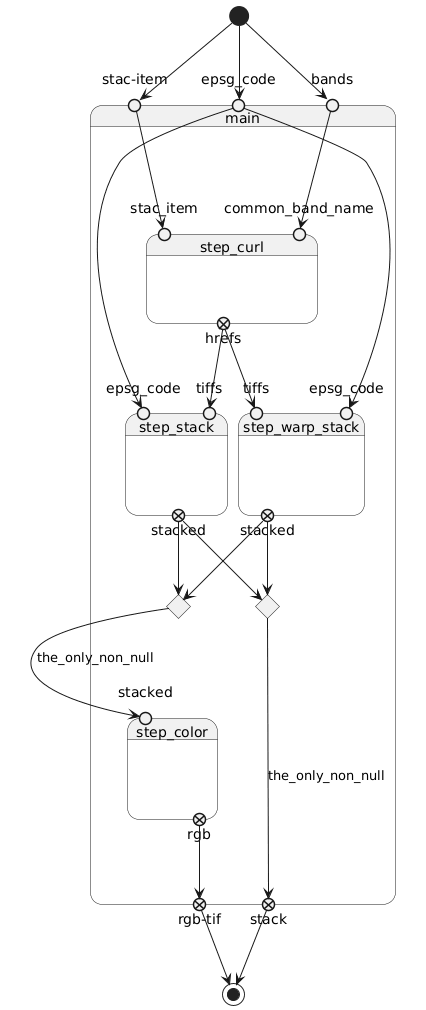

In [8]:
render(DiagramType.STATE)